# Notebook 2 — Regresi Prediksi IPK Mahasiswa
**Mata Kuliah:** Pembelajaran Mesin — UAS Genap T.A. 2025/2026  
**Program Studi:** Informatika, Universitas Atma Jaya Yogyakarta  
**Dosen:** Yohanes Sigit Purnomo, Ph.D. & Theresia Devi Indriasari, Ph.D.

---
**Tujuan:** Membangun model regresi untuk memprediksi **IPK kumulatif** mahasiswa  
berdasarkan gaya belajar (LearningStyle), kebiasaan belajar, lingkungan, teknologi, dan faktor akademik.


## 1. Import Library

In [49]:
# ── Library standar & data manipulation ──────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute           import SimpleImputer

# ── Scikit-learn: Feature Selection ──────────────────────────────────────────
from sklearn.feature_selection import (SelectKBest, SelectPercentile,
                                        f_regression, mutual_info_regression)

# ── Scikit-learn: Model Split & Validation ────────────────────────────────────
from sklearn.model_selection  import (train_test_split, GridSearchCV,
                                       KFold, cross_validate, cross_val_score)

# ── Scikit-learn: Regressor ───────────────────────────────────────────────────
from sklearn.linear_model     import LinearRegression, Ridge
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm              import SVR

# ── Scikit-learn: Evaluasi ────────────────────────────────────────────────────
from sklearn.metrics          import (r2_score, mean_absolute_error,
                                       mean_squared_error)

# ── Export model ──────────────────────────────────────────────────────────────
import joblib

# ── Konstanta ─────────────────────────────────────────────────────────────────
RANDOM_STATE = 99
print("✅ Semua library berhasil diimport.")
print(f"   RANDOM_STATE = {RANDOM_STATE}")


✅ Semua library berhasil diimport.
   RANDOM_STATE = 99


## 2. Data Loading
Dataset yang digunakan adalah hasil survei preferensi belajar, kebiasaan belajar, dan faktor akademik mahasiswa yang telah **dianonimkan**.


In [50]:
FILE_PATH = 'ANONIM_Survei Preferensi Belajar, Kebiasaan Belajar, dan Faktor Akademik Mahasiswa (Responses).xlsx'
df_raw = pd.read_excel(FILE_PATH)

print(f"Shape: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")


Shape: 324 baris × 89 kolom


In [51]:
df_raw.head(3)

,Timestamp,Pernyataan Persetujuan,Program studi,Semester saat ini,Jenis kelamin,Usia (tahun),Status tempat tinggal selama kuliah,Apakah Anda bekerja sambil kuliah?,Sumber pembiayaan utama kuliah saya saat ini adalah:,Rata-rata waktu belajar mandiri per hari di luar jam kuliah,...,"Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir,"Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?","Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E?"
0,2026-03-17 16:11:14.219,Saya BERSEDIA mengikuti survei ini secara suka...,Arsitektur,6,Perempuan,20.0,Kost/asrama,Tidak,"Orang tua / keluarga, Beasiswa sebagian",1–2 jam,...,3.0,3.0,3.0,3.0,4.0,3.0,3.20,2.80,Tidak,Tidak
1,2026-03-17 16:23:55.853,Saya BERSEDIA mengikuti survei ini secara suka...,informatika,6,Perempuan,21.0,Bersama orang tua,Tidak,"Orang tua / keluarga, Beasiswa penuh",2–3 jam,...,3.0,3.0,3.0,2.0,3.0,4.0,3.07,3.91,Tidak,Tidak
2,2026-03-17 16:31:47.507,Saya BERSEDIA mengikuti survei ini secara suka...,Informatika,6,Laki-laki,20.0,Bersama orang tua,Tidak,Orang tua / keluarga,Kurang dari 1 jam,...,4.0,4.0,3.0,4.0,4.0,4.0,3.51,3.51,Tidak,Tidak


In [52]:
df_raw.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 89 columns):
 #   Column                                                                                                                         Non-Null Count  Dtype         
---  ------                                                                                                                         --------------  -----         
 0   Timestamp                                                                                                                      324 non-null    datetime64[ns]
 1   Pernyataan Persetujuan                                                                                                         324 non-null    object        
 2    Program studi                                                                                                                 323 non-null    object        
 3    Semester saat ini                                                         

In [53]:
df_raw.describe().round(2)

,Timestamp,Usia (tahun),Kualitas akses internet untuk belajar,Kehadiran perkuliahan saya selama satu semester terakhir secara umum,"Saya lebih mudah memahami materi jika disajikan dalam bentuk diagram, bagan, atau infografik.",Saya lebih mudah mengingat materi ketika dosen menggunakan slide yang jelas dan visual.,"Warna, simbol, atau penanda visual membantu saya memahami konsep.",Saya lebih suka membuat peta konsep atau mind map saat belajar.,Saya lebih cepat memahami penjelasan jika disertai ilustrasi atau video.,Saya lebih mudah memahami materi dengan mendengarkan penjelasan lisan dosen.,...,"Saat menemukan materi yang sulit, saya mencari penjelasan tertulis dari buku, modul, artikel, atau internet.","Saat menghafal konsep atau istilah, saya menuliskannya berulang kali agar lebih ingat.","Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir
count,324,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,...,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00,323.00
mean,2026-04-21 19:47:46.415814912,20.93,4.04,4.58,3.73,4.32,4.36,3.48,4.31,3.75,...,4.02,3.77,3.87,3.93,3.99,3.73,4.02,4.05,10.91,10.32
min,2026-03-17 16:11:14.219000,18.00,1.00,2.00,1.00,1.00,2.00,1.00,2.00,1.00,...,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,0.00
25%,2026-04-14 22:12:47.149500160,20.00,4.00,4.00,3.00,4.00,4.00,3.00,4.00,3.00,...,3.00,3.00,3.00,3.00,3.00,3.00,3.50,3.50,3.36,3.50
50%,2026-04-25 00:01:07.254500096,21.00,4.00,5.00,4.00,4.00,4.00,3.00,4.00,4.00,...,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,3.60,3.70
75%,2026-04-28 21:40:19.310249984,21.00,5.00,5.00,4.00,5.00,5.00,4.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,3.80,3.90
max,2026-05-02 14:11:52.871000,26.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,390.00,380.00
std,NaN,1.21,0.84,0.68,0.93,0.78,0.71,1.12,0.80,0.99,...,0.83,1.08,0.92,0.84,0.88,1.01,0.83,0.83,49.99,45.20


## 3. Exploratory Data Analysis (EDA)

In [54]:
print(f"Jumlah data      : {df_raw.shape[0]}")
print(f"Jumlah kolom     : {df_raw.shape[1]}")
print()
dtype_summary = df_raw.dtypes.value_counts()
print("Tipe data:")
for dtype, count in dtype_summary.items():
    print(f"  {dtype}: {count} kolom")


Jumlah data      : 324
Jumlah kolom     : 89

Tipe data:
  float64: 77 kolom
  object: 11 kolom
  datetime64[ns]: 1 kolom


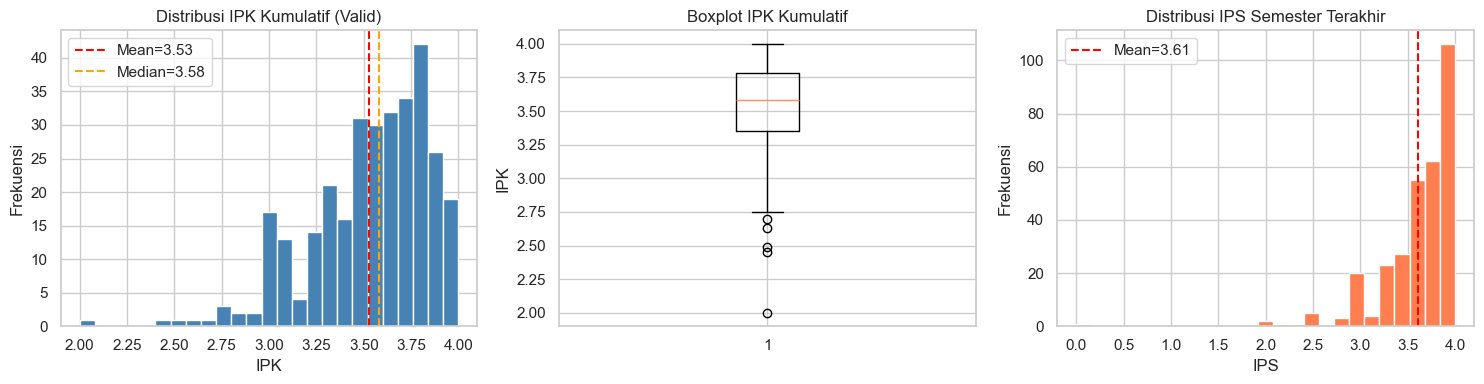

Statistik IPK (valid 0-4):
count    311.000
mean       3.528
std        0.317
min        2.000
25%        3.350
50%        3.580
75%        3.780
max        4.000
Name:   IPK kumulatif saat ini  , dtype: float64

Interpretasi: IPK terdistribusi sedikit left-skewed dengan mayoritas responden
memiliki IPK di rentang 3.0–3.9. Terdapat beberapa nilai outlier yang perlu ditangani.


In [55]:
# ── Distribusi target IPK ─────────────────────────────────────────────────────
col_ipk = '  IPK kumulatif saat ini  '
col_ips = ' IPS semester terakhir  '

# Hanya tampilkan nilai valid (0-4) untuk EDA awal
ipk_valid = df_raw[df_raw[col_ipk].between(0, 4.0)][col_ipk].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram IPK
axes[0].hist(ipk_valid, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(ipk_valid.mean(), color='red', linestyle='--', label=f'Mean={ipk_valid.mean():.2f}')
axes[0].axvline(ipk_valid.median(), color='orange', linestyle='--', label=f'Median={ipk_valid.median():.2f}')
axes[0].set_title('Distribusi IPK Kumulatif (Valid)')
axes[0].set_xlabel('IPK'); axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot IPK
axes[1].boxplot(ipk_valid, vert=True)
axes[1].set_title('Boxplot IPK Kumulatif')
axes[1].set_ylabel('IPK')

# IPS valid
ips_valid = df_raw[df_raw[col_ips].between(0, 4.0)][col_ips].dropna()
axes[2].hist(ips_valid, bins=25, color='coral', edgecolor='white')
axes[2].axvline(ips_valid.mean(), color='red', linestyle='--', label=f'Mean={ips_valid.mean():.2f}')
axes[2].set_title('Distribusi IPS Semester Terakhir')
axes[2].set_xlabel('IPS'); axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_ipk_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Statistik IPK (valid 0-4):")
print(ipk_valid.describe().round(3))
print()
print("Interpretasi: IPK terdistribusi sedikit left-skewed dengan mayoritas responden")
print("memiliki IPK di rentang 3.0–3.9. Terdapat beberapa nilai outlier yang perlu ditangani.")


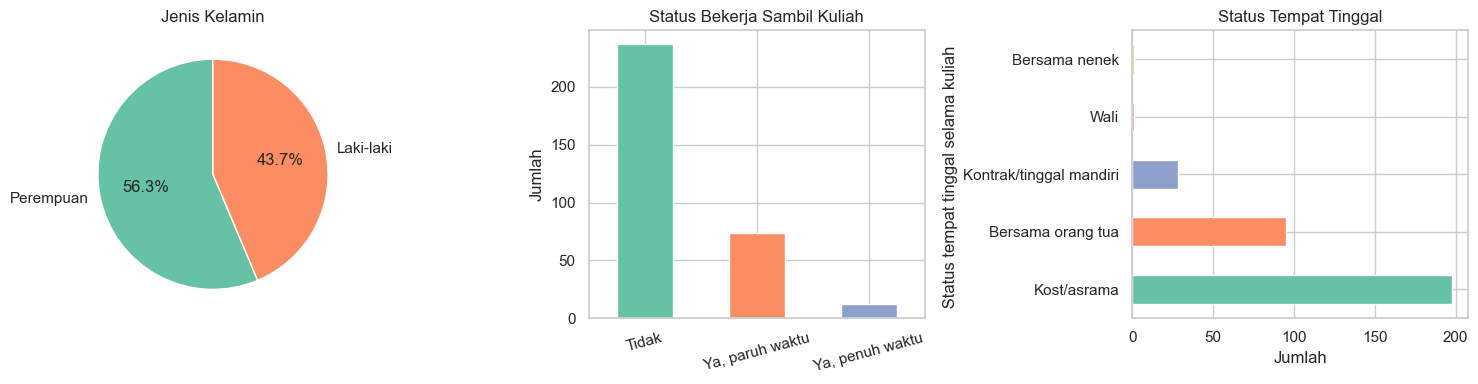

Interpretasi: Mayoritas responden perempuan, tidak bekerja sambil kuliah,
dan tinggal di kost/asrama.


In [56]:
# ── Distribusi variabel demografis ───────────────────────────────────────────
col_gender = ' Jenis kelamin  '
col_kerja  = ' Apakah Anda bekerja sambil kuliah?  '
col_tinggal = ' Status tempat tinggal selama kuliah  '

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Jenis kelamin
gc = df_raw[col_gender].value_counts()
axes[0].pie(gc, labels=gc.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(gc)))
axes[0].set_title('Jenis Kelamin')

# Bekerja sambil kuliah
wc = df_raw[col_kerja].value_counts()
wc.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', len(wc)))
axes[1].set_title('Status Bekerja Sambil Kuliah')
axes[1].set_xlabel(''); axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=15)

# Status tempat tinggal
tc = df_raw[col_tinggal].value_counts()
tc.plot(kind='barh', ax=axes[2], color=sns.color_palette('Set2', len(tc)))
axes[2].set_title('Status Tempat Tinggal')
axes[2].set_xlabel('Jumlah')

plt.tight_layout()
plt.savefig('eda_demografi.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Mayoritas responden perempuan, tidak bekerja sambil kuliah,")
print("dan tinggal di kost/asrama.")


## 4. Data Checking

In [57]:
# ── Missing Value ─────────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
print(f"Kolom dengan missing value: {len(missing_df)}")
display(missing_df.head(15))


Kolom dengan missing value: 87


,Missing,Persen (%)
Program studi,1,0.31
Semester saat ini,1,0.31
Jenis kelamin,1,0.31
Usia (tahun),1,0.31
Status tempat tinggal selama kuliah,1,0.31
Apakah Anda bekerja sambil kuliah?,1,0.31
Sumber pembiayaan utama kuliah saya saat ini adalah:,1,0.31
Rata-rata waktu belajar mandiri per hari di luar jam kuliah,1,0.31
Perangkat utama yang digunakan untuk belajar,1,0.31
Kualitas akses internet untuk belajar,1,0.31


In [58]:
# ── Empty String ──────────────────────────────────────────────────────────────
obj_cols = df_raw.select_dtypes(include='object').columns
empty_str = {c: (df_raw[c].astype(str).str.strip() == '').sum()
             for c in obj_cols}
empty_str = {k: v for k, v in empty_str.items() if v > 0}
print("Kolom dengan empty string:", empty_str if empty_str else "Tidak ada")

# ── Duplikasi ──────────────────────────────────────────────────────────────────
print(f"Baris duplikat: {df_raw.duplicated().sum()}")


Kolom dengan empty string: Tidak ada
Baris duplikat: 0


In [59]:
# ── Outlier pada kolom target IPK ─────────────────────────────────────────────
col_ipk = '  IPK kumulatif saat ini  '

print("Statistik IPK (sebelum cleaning):")
print(df_raw[col_ipk].describe().round(3))
print()
print(f"IPK > 4.0  : {(df_raw[col_ipk] > 4.0).sum()} baris  ← outlier / salah input")
print(f"IPK < 0.0  : {(df_raw[col_ipk] < 0.0).sum()} baris")
print()
print("Nilai IPK tidak valid (> 4.0):")
display(df_raw[df_raw[col_ipk] > 4.0][[col_ipk, ' IPS semester terakhir  ']].reset_index())


Statistik IPK (sebelum cleaning):
count    323.000
mean      10.907
std       49.993
min        2.000
25%        3.365
50%        3.600
75%        3.800
max      390.000
Name:   IPK kumulatif saat ini  , dtype: float64

IPK > 4.0  : 12 baris  ← outlier / salah input
IPK < 0.0  : 0 baris

Nilai IPK tidak valid (> 4.0):


,index,IPK kumulatif saat ini,IPS semester terakhir
0,117,367.0,363.0
1,151,39.0,4.0
2,164,370.0,369.0
3,176,38.0,36.0
4,190,361.0,252.0
5,205,35.0,36.0
6,230,4.7,4.9
7,246,375.0,38.0
8,285,390.0,380.0
9,286,371.0,257.0


In [60]:
# ── Outlier pada kolom Likert (IQR) ──────────────────────────────────────────
likert_cols = list(df_raw.columns[13:33]) + list(df_raw.columns[64:84])
outlier_summary = []
for c in likert_cols:
    vals = df_raw[c].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((vals < Q1 - 1.5*IQR) | (vals > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_summary.append({'Kolom': c.strip()[:55], 'Outlier': n_out})

print(f"Kolom Likert dengan outlier (IQR): {len(outlier_summary)}")
if outlier_summary:
    display(pd.DataFrame(outlier_summary).head(10))
print()
print("Catatan: Outlier pada skala Likert 1-5 tidak dihapus karena range nilai memang")
print("terbatas dan nilai ekstrem tetap valid secara psikometri.")


Kolom Likert dengan outlier (IQR): 20


,Kolom,Outlier
0,Saya lebih mudah memahami materi jika disajika...,4
1,Saya lebih mudah mengingat materi ketika dosen...,8
2,"Warna, simbol, atau penanda visual membantu sa...",3
3,Saya lebih suka membuat peta konsep atau mind ...,13
4,Saya lebih cepat memahami penjelasan jika dise...,7
5,Saya sering mengulang materi dengan membacanya...,17
6,"Saya lebih suka belajar dari buku, modul, atau...",7
7,Saya lebih mudah memahami materi dengan mencat...,9
8,Saya suka membuat rangkuman tertulis setelah p...,11
9,Saya lebih nyaman menerima instruksi dalam ben...,9



Catatan: Outlier pada skala Likert 1-5 tidak dihapus karena range nilai memang
terbatas dan nilai ekstrem tetap valid secara psikometri.


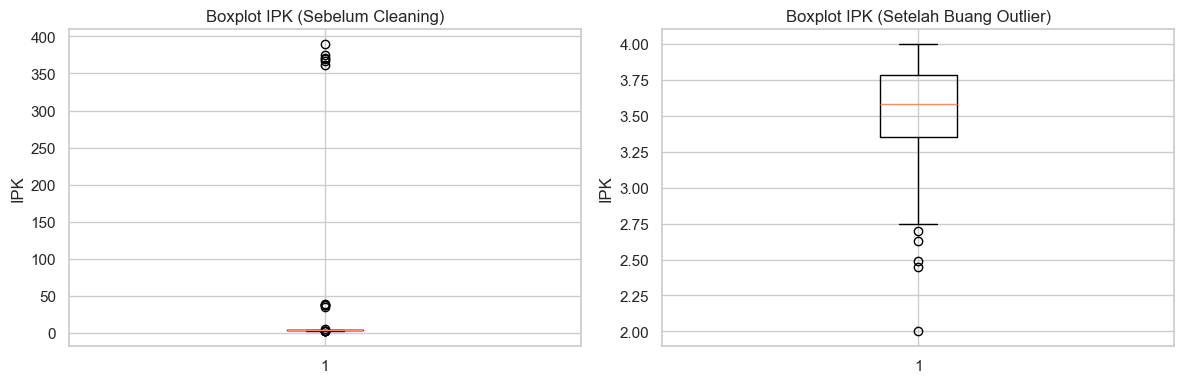

Interpretasi: Terdapat 12 baris dengan IPK > 4.0 yang merupakan salah input
(misalnya 3.67 diinput sebagai 367). Baris-baris ini akan dihapus.


In [61]:
# ── Visualisasi outlier IPK ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_raw[col_ipk].dropna(), vert=True)
axes[0].set_title('Boxplot IPK (Sebelum Cleaning)')
axes[0].set_ylabel('IPK')

ipk_valid_check = df_raw[df_raw[col_ipk].between(0, 4.0)][col_ipk].dropna()
axes[1].boxplot(ipk_valid_check, vert=True)
axes[1].set_title('Boxplot IPK (Setelah Buang Outlier)')
axes[1].set_ylabel('IPK')

plt.tight_layout()
plt.savefig('check_outlier_ipk.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Terdapat 12 baris dengan IPK > 4.0 yang merupakan salah input")
print("(misalnya 3.67 diinput sebagai 367). Baris-baris ini akan dihapus.")


## 5. Data Preparation
Langkah persiapan data:
1. Hapus kolom identitas & administrasi (Timestamp, Pernyataan Persetujuan)
2. Hapus kolom duplikat (D1.4 duplikat, C4.5 konfirmasi duplikat)
3. Hapus baris dengan IPK tidak valid (> 4.0) — salah input
4. Hapus baris dengan missing value massif
5. Reverse coding item negatif (E5, F5) sesuai panduan survei


In [62]:
df = df_raw.copy()

# ── 5.1 Hapus kolom identitas & administrasi ──────────────────────────────────
drop_admin = [df.columns[0], df.columns[1]]  # Timestamp, Pernyataan Persetujuan
df.drop(columns=drop_admin, inplace=True)
print(f"[1] Hapus kolom admin → {df.shape}")


[1] Hapus kolom admin → (324, 87)


In [63]:
# ── 5.2 Hapus kolom duplikat ──────────────────────────────────────────────────
dup_cols = [c for c in df.columns if c.rstrip().endswith(' 2')]
print(f"Kolom duplikat: {len(dup_cols)}")
for c in dup_cols:
    print(f"  → {c.strip()[:70]}")
df.drop(columns=dup_cols, inplace=True)
print(f"[2] Hapus kolom duplikat → {df.shape}")


Kolom duplikat: 2
  → Saya jarang menunda mengerjakan tugas sampai mendekati tenggat waktu. 
  → Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara k
[2] Hapus kolom duplikat → (324, 85)


In [64]:
# ── 5.3 Hapus baris IPK tidak valid (> 4.0) ──────────────────────────────────
col_ipk = '  IPK kumulatif saat ini  '
n_before = len(df)
df = df[df[col_ipk].between(0, 4.0) | df[col_ipk].isnull()].copy()
print(f"[3] Hapus IPK > 4.0 → {n_before - len(df)} baris dihapus → sisa {len(df)}")


[3] Hapus IPK > 4.0 → 12 baris dihapus → sisa 312


In [65]:
# ── 5.4 Hapus baris missing value massif ──────────────────────────────────────
n_before = len(df)
df.dropna(thresh=int(len(df.columns) * 0.5), inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"[4] Hapus baris missing > 50% kolom → {n_before - len(df)} baris dihapus → sisa {len(df)}")

# Hapus sisa baris dengan IPK kosong (target tidak boleh NaN)
n_before = len(df)
df.dropna(subset=[col_ipk], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"[5] Hapus baris tanpa IPK → {n_before - len(df)} baris → sisa {len(df)}")


[4] Hapus baris missing > 50% kolom → 1 baris dihapus → sisa 311
[5] Hapus baris tanpa IPK → 0 baris → sisa 311


In [66]:
# ── 5.5 Reverse coding ───────────────────────────────────────────────────────
# E5: Hambatan teknis mengganggu belajar  (reverse: tinggi = gangguan → dibalik jadi kondusif)
# F5: Mudah terdistraksi perangkat digital (reverse: tinggi = terdistraksi → dibalik)
def reverse_code(series):
    return 6 - series

col_E5 = [c for c in df.columns if 'Hambatan teknis' in c][0]
col_F5 = [c for c in df.columns if 'terdistraksi' in c][0]

df[col_E5] = reverse_code(df[col_E5])
df[col_F5] = reverse_code(df[col_F5])
print(f"[6] Reverse coding selesai: E5 dan F5 dibalik.")

# ── 5.6 Standarisasi nilai kategorikal ───────────────────────────────────────
col_prodi = ' Program studi  '
df[col_prodi] = df[col_prodi].astype(str).str.strip().str.title()
print(f"[7] Program studi distandarkan → {df[col_prodi].nunique()} nilai unik")

print(f"\n✅ Dataset bersih: {df.shape}")


[6] Reverse coding selesai: E5 dan F5 dibalik.
[7] Program studi distandarkan → 86 nilai unik

✅ Dataset bersih: (311, 85)


## 6. Feature Engineering — Membuat LearningStyle
LearningStyle dibuat ulang menggunakan aturan yang sama dengan Notebook 1:
- Hitung rata-rata 10 item per dimensi (5 attitude + 5 konfirmasi)
- Label = dimensi dengan skor tertinggi


In [67]:
# ── Definisi kolom VARK ───────────────────────────────────────────────────────
visual_att    = [c for c in df.columns if any(k in c for k in [
    'diagram, bagan, atau infografik',
    'slide yang jelas dan visual',
    'Warna, simbol, atau penanda visual',
    'peta konsep atau mind map saat belajar',
    'ilustrasi atau video'])]

auditory_att  = [c for c in df.columns if any(k in c for k in [
    'mendengarkan penjelasan lisan dosen',
    'Diskusi kelas atau diskusi kelompok',
    'membacanya keras-keras atau menjelaskannya secara verbal',
    'mendengar contoh yang dijelaskan secara lisan',
    'rekaman audio atau penjelasan verbal membantu'])]

readwrite_att = [c for c in df.columns if any(k in c for k in [
    'buku, modul, atau artikel tertulis',
    'mencatat ulang poin-poin penting',
    'rangkuman tertulis setelah perkuliahan',
    'instruksi dalam bentuk tulisan daripada penjelasan lisan',
    'istilah atau konsep ketika menuliskannya'])]

kinesthetic_att = [c for c in df.columns if any(k in c for k in [
    'langsung mempraktikkannya',
    'Contoh kasus nyata membuat saya lebih cepat',
    'simulasi, eksperimen, atau demonstrasi',
    'mencoba sendiri langkah-langkahnya',
    'praktik daripada hanya membaca teori'])]

visual_conf    = [c for c in df.columns if any(k in c for k in [
    'slide, diagram, bagan, atau infografik untuk memahami',
    'mencari video pembelajaran untuk membantu',
    'highlight, warna, simbol, atau tanda khusus',
    'mind map, peta konsep, atau skema ringkas',
    'gambar, ilustrasi, tabel, atau tampilan visual lain'])]

auditory_conf  = [c for c in df.columns if any(k in c for k in [
    'mendengarkan ulang rekaman penjelasan atau audio',
    'suara keras agar lebih mudah memahami isi',
    'menjelaskan materi dengan lisan kepada diri sendiri',
    'berdiskusi dengan teman, baik secara langsung',
    'penjelasan berbentuk suara atau video yang menjelaskan materi secara verbal'])]

readwrite_conf = [c for c in df.columns if any(k in c for k in [
    'membaca ulang catatan kuliah, modul',
    'menulis ulang poin-poin penting dari materi',
    'rangkuman tertulis dengan bahasa saya sendiri',
    'penjelasan tertulis dari buku, modul, artikel, atau internet',
    'menuliskannya berulang kali agar lebih ingat'])]

kinesthetic_conf = [c for c in df.columns if any(k in c for k in [
    'latihan soal, tugas, atau kuis untuk memahami',
    'mencoba langsung langkah-langkah atau prosedur',
    'contoh kasus nyata agar lebih mudah memahami konsep',
    'simulasi, praktik, eksperimen, atau demonstrasi kecil',
    'mencoba sendiri sampai mengetahui cara kerja'])]

# Gabungkan
visual_all      = visual_att    + visual_conf
auditory_all    = auditory_att  + auditory_conf
readwrite_all   = readwrite_att + readwrite_conf
kinesthetic_all = kinesthetic_att + kinesthetic_conf

print("Jumlah item per dimensi VARK:")
for name, cols in [('Visual', visual_all), ('Auditory', auditory_all),
                    ('ReadWrite', readwrite_all), ('Kinesthetic', kinesthetic_all)]:
    print(f"  {name}: {len(cols)} item")


Jumlah item per dimensi VARK:
  Visual: 11 item
  Auditory: 10 item
  ReadWrite: 10 item
  Kinesthetic: 10 item


In [68]:
# ── Hitung skor & buat label LearningStyle ───────────────────────────────────
df['score_Visual']      = df[visual_all].mean(axis=1)
df['score_Auditory']    = df[auditory_all].mean(axis=1)
df['score_ReadWrite']   = df[readwrite_all].mean(axis=1)
df['score_Kinesthetic'] = df[kinesthetic_all].mean(axis=1)

score_cols = ['score_Visual', 'score_Auditory', 'score_ReadWrite', 'score_Kinesthetic']
df['LearningStyle'] = df[score_cols].idxmax(axis=1).map({
    'score_Visual'     : 'Visual',
    'score_Auditory'   : 'Auditory',
    'score_ReadWrite'  : 'ReadWrite',
    'score_Kinesthetic': 'Kinesthetic'
})

print("Distribusi LearningStyle:")
print(df['LearningStyle'].value_counts())


Distribusi LearningStyle:
LearningStyle
Kinesthetic    153
Visual          71
ReadWrite       52
Auditory        35
Name: count, dtype: int64


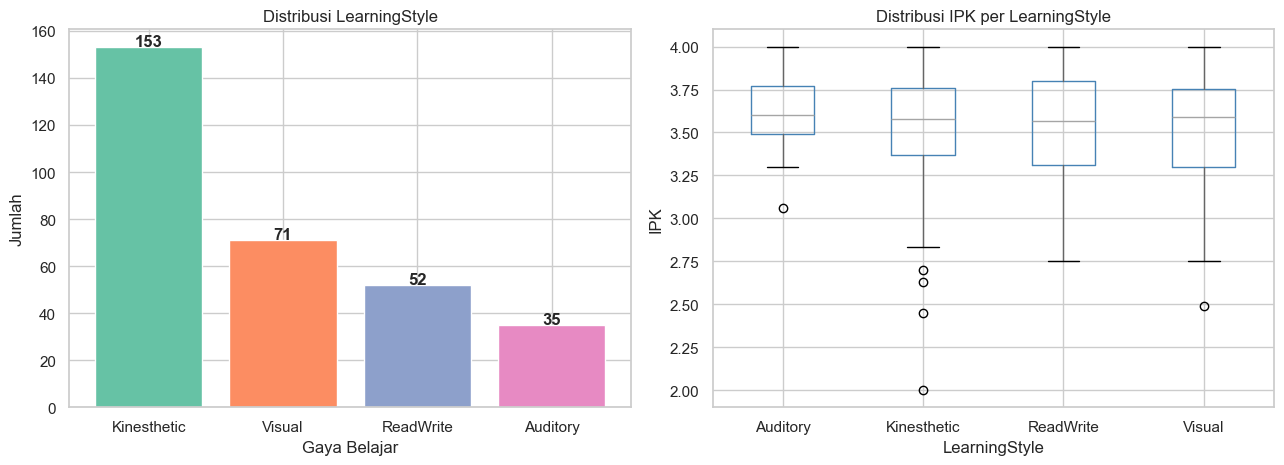

Interpretasi: Boxplot IPK per LearningStyle menunjukkan apakah gaya belajar
berkaitan dengan performa akademik. Perbedaan median IPK antar gaya belajar
akan memengaruhi kontribusi fitur LearningStyle dalam model regresi.


In [69]:
# ── Visualisasi distribusi LearningStyle ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
ls_counts = df['LearningStyle'].value_counts()
colors = sns.color_palette('Set2', 4)
bars = axes[0].bar(ls_counts.index, ls_counts.values, color=colors)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                  str(int(bar.get_height())), ha='center', fontweight='bold')
axes[0].set_title('Distribusi LearningStyle')
axes[0].set_xlabel('Gaya Belajar'); axes[0].set_ylabel('Jumlah')

# Boxplot IPK per LearningStyle
df.boxplot(column=col_ipk, by='LearningStyle', ax=axes[1],
           boxprops=dict(color='steelblue'))
axes[1].set_title('Distribusi IPK per LearningStyle')
axes[1].set_xlabel('LearningStyle'); axes[1].set_ylabel('IPK')
plt.suptitle('')

plt.tight_layout()
plt.savefig('learning_style_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Boxplot IPK per LearningStyle menunjukkan apakah gaya belajar")
print("berkaitan dengan performa akademik. Perbedaan median IPK antar gaya belajar")
print("akan memengaruhi kontribusi fitur LearningStyle dalam model regresi.")


## 7. Menentukan Fitur dan Target

**Target (y):** `IPK kumulatif saat ini`

**Fitur (X):**
- **LearningStyle** (kategorikal) — gaya belajar dominan hasil rekayasa fitur
- **Demografi:** jenis kelamin, usia, semester, status tinggal, status kerja (numerik + kategorikal)
- **Kebiasaan Belajar (D1–D4):** manajemen waktu, strategi, motivasi, keterlibatan (numerikal, 20 item)
- **Lingkungan Belajar (E1–E5):** kondisi tempat belajar, dukungan sosial (numerikal, 5 item)
- **Teknologi Belajar (F1–F5):** penggunaan platform digital, efektivitas online (numerikal, 5 item)
- **Waktu belajar harian, kualitas internet, kehadiran** (numerik/kategorikal)
- **IPS semester terakhir** — numerik, berkorelasi kuat dengan IPK kumulatif
- **Mengulang & nilai D/E** — indikator kesulitan akademik (kategorikal)

**Kolom TIDAK digunakan:**
- 40 item VARK (C1–C4) → membentuk LearningStyle, bukan prediktor langsung IPK
- `score_Visual/Auditory/ReadWrite/Kinesthetic` → turunan LearningStyle (data leakage)
- `Program studi`, `Sumber pembiayaan` → variasi tinggi, kurang reliabel
- `Timestamp`, `Pernyataan Persetujuan` → bukan informasi responden


In [70]:
# ── Fitur kategorikal ─────────────────────────────────────────────────────────
CAT_FEATURES = [
    ' Jenis kelamin  ',
    ' Status tempat tinggal selama kuliah  ',
    ' Apakah Anda bekerja sambil kuliah?  ',
    ' Rata-rata waktu belajar mandiri per hari di luar jam kuliah  ',
    ' Perangkat utama yang digunakan untuk belajar  ',
    'Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?  ',
    'Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E? ',
    'LearningStyle',
]

# ── Fitur numerikal base ──────────────────────────────────────────────────────
NUM_BASE = [
    ' Usia  (tahun)',
    ' Kualitas akses internet untuk belajar  ',
    ' Kehadiran perkuliahan saya selama satu semester terakhir secara umum  ',
    ' IPS semester terakhir  ',
]

# Konversi semester ke numerik
df[' Semester saat ini  '] = pd.to_numeric(df[' Semester saat ini  '], errors='coerce')
NUM_BASE.append(' Semester saat ini  ')

# ── Kolom D (Kebiasaan Belajar, 20 item) ─────────────────────────────────────
D_COLS = [c for c in df.columns if any(k in c for k in [
    'jadwal belajar yang cukup teratur',
    'membagi waktu belajar jauh sebelum ujian',
    'menentukan prioritas antara kuliah',
    'jarang menunda mengerjakan tugas',
    'konsisten mengalokasikan waktu khusus',
    'meninjau kembali materi kuliah setelah',
    'mencari sumber tambahan ketika ada materi',
    'membandingkan berbagai sumber untuk',
    'membuat ringkasan, poin penting, atau catatan pribadi',
    'mengecek sendiri apakah saya benar-benar',
    'memiliki target akademik yang jelas',
    'tetap berusaha memahami materi walaupun terasa sulit',
    'terdorong untuk belajar bukan hanya demi nilai',
    'merasa bertanggung jawab terhadap hasil',
    'berusaha memperbaiki strategi belajar ketika',
    'aktif bertanya atau berdiskusi ketika ada materi',
    'mengerjakan tugas kuliah dengan sungguh',
    'mengikuti perkuliahan dengan fokus',
    'berusaha hadir tepat waktu dalam perkuliahan',
    'memanfaatkan umpan balik dari dosen'])]

# ── Kolom E (Lingkungan Belajar, 5 item) ─────────────────────────────────────
E_COLS = [c for c in df.columns if any(k in c for k in [
    'tempat belajar yang cukup nyaman',
    'lingkungan tempat saya belajar mendukung',
    'akses perangkat yang memadai',
    'dukungan sosial yang cukup',
    'Hambatan teknis seperti internet'])]

# ── Kolom F (Teknologi Belajar, 5 item) ──────────────────────────────────────
F_COLS = [c for c in df.columns if any(k in c for k in [
    'platform digital untuk memahami',
    'Video pembelajaran atau tutorial online',
    'aplikasi atau tools digital untuk mencatat',
    'belajar secara efektif melalui media pembelajaran online',
    'terdistraksi oleh penggunaan perangkat digital'])]

NUM_FEATURES = NUM_BASE + D_COLS + E_COLS + F_COLS
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES

print(f"Fitur kategorikal : {len(CAT_FEATURES)}")
print(f"Fitur numerikal   : {len(NUM_FEATURES)}")
print(f"  Numerik base    : {len(NUM_BASE)}")
print(f"  Kolom D         : {len(D_COLS)}")
print(f"  Kolom E         : {len(E_COLS)}")
print(f"  Kolom F         : {len(F_COLS)}")
print(f"Total fitur       : {len(ALL_FEATURES)}")


Fitur kategorikal : 8
Fitur numerikal   : 35
  Numerik base    : 5
  Kolom D         : 20
  Kolom E         : 5
  Kolom F         : 5
Total fitur       : 43


In [71]:
# ── Pisahkan X dan y ──────────────────────────────────────────────────────────
X = df[ALL_FEATURES].copy()
y = df[col_ipk].copy()

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"\nTarget (IPK) — statistik:")
print(y.describe().round(3))


Shape X : (311, 43)
Shape y : (311,)

Target (IPK) — statistik:
count    311.000
mean       3.528
std        0.317
min        2.000
25%        3.350
50%        3.580
75%        3.780
max        4.000
Name:   IPK kumulatif saat ini  , dtype: float64


## 8. Korelasi dan Analisis Fitur

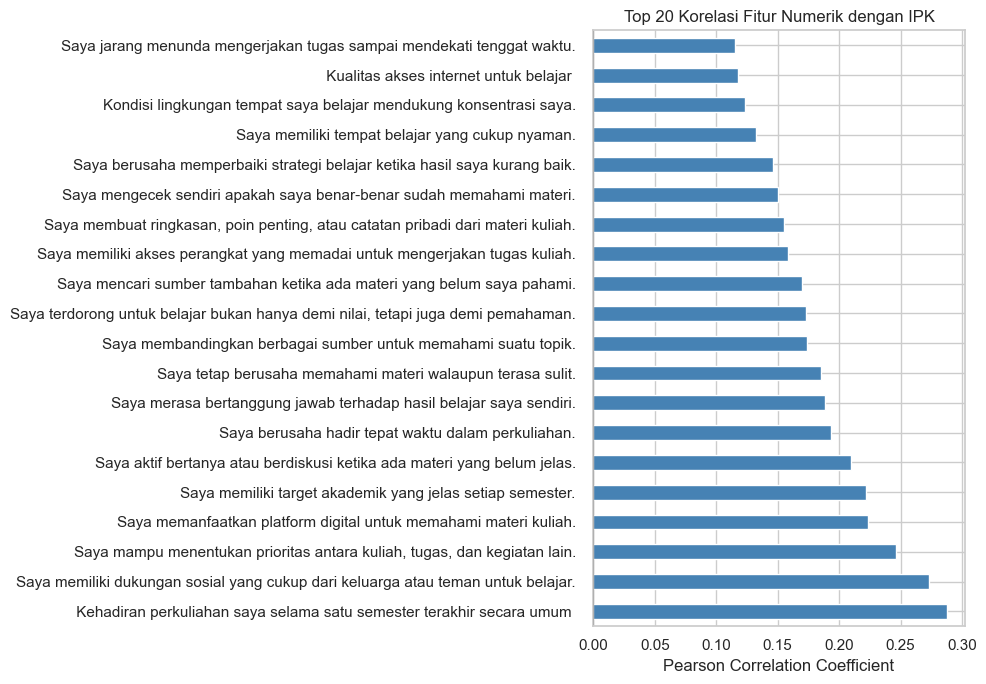

Top 10 fitur berkorelasi dengan IPK:
 Kehadiran perkuliahan saya selama satu semester terakhir secara umum                0.288
Saya memiliki dukungan sosial yang cukup dari keluarga atau teman untuk belajar.     0.273
Saya mampu menentukan prioritas antara kuliah, tugas, dan kegiatan lain.             0.246
Saya memanfaatkan platform digital untuk memahami materi kuliah.                     0.224
Saya memiliki target akademik yang jelas setiap semester.                            0.222
Saya aktif bertanya atau berdiskusi ketika ada materi yang belum jelas.              0.210
Saya berusaha hadir tepat waktu dalam perkuliahan.                                   0.193
Saya merasa bertanggung jawab terhadap hasil belajar saya sendiri.                   0.189
Saya tetap berusaha memahami materi walaupun terasa sulit.                           0.185
Saya membandingkan berbagai sumber untuk memahami suatu topik.                       0.174

Interpretasi: Fitur dengan korelasi positif tinggi b

In [72]:
# ── Korelasi fitur numerik dengan IPK ────────────────────────────────────────
num_data = df[NUM_FEATURES + [col_ipk]].copy()
corr_with_ipk = num_data.corr()[col_ipk].drop(col_ipk).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))
colors = ['steelblue' if v >= 0 else 'coral' for v in corr_with_ipk.values]
corr_with_ipk.head(20).plot(kind='barh', color=colors[:20])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 20 Korelasi Fitur Numerik dengan IPK')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('correlation_with_ipk.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 10 fitur berkorelasi dengan IPK:")
print(corr_with_ipk.head(10).round(3).to_string())
print()
print("Interpretasi: Fitur dengan korelasi positif tinggi berkontribusi meningkatkan IPK,")
print("sedangkan korelasi negatif menunjukkan hubungan berlawanan. IPS semester terakhir")
print("diharapkan berkorelasi kuat karena berkaitan langsung dengan performa akademik.")


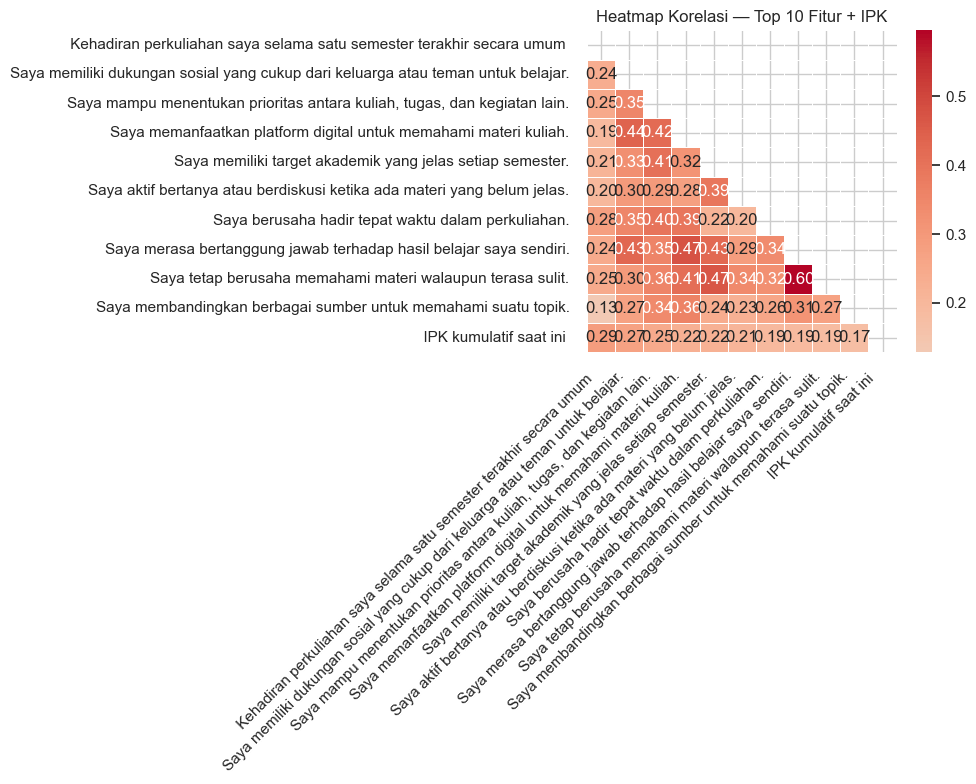

Interpretasi: Heatmap menampilkan korelasi antar fitur terpilih dan target IPK.
Perhatikan multikolinearitas antar fitur — jika dua fitur berkorelasi tinggi,
salah satunya mungkin redundan.


In [73]:
# ── Heatmap korelasi fitur penting ───────────────────────────────────────────
top_corr_cols = corr_with_ipk.head(10).index.tolist() + [col_ipk]
corr_matrix = df[top_corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Heatmap Korelasi — Top 10 Fitur + IPK')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Heatmap menampilkan korelasi antar fitur terpilih dan target IPK.")
print("Perhatikan multikolinearitas antar fitur — jika dua fitur berkorelasi tinggi,")
print("salah satunya mungkin redundan.")


## 9. Train Test Split
Membandingkan rasio **80:20** dan **75:25** untuk memilih yang optimal.


In [74]:
from sklearn.linear_model import Ridge as RidgeCheck

# ── Uji coba dua rasio split ──────────────────────────────────────────────────
results_split = []
for test_sz, label in [(0.20, '80:20'), (0.25, '75:25')]:
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=test_sz, random_state=RANDOM_STATE)

    # Preprocessing sederhana untuk perbandingan
    num_tr = Xtr[NUM_FEATURES].apply(pd.to_numeric, errors='coerce')
    num_te = Xte[NUM_FEATURES].apply(pd.to_numeric, errors='coerce')
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    imp = SimpleImputer(strategy='median')
    scl = StandardScaler()
    Xtr_s = scl.fit_transform(imp.fit_transform(num_tr))
    Xte_s = scl.transform(imp.transform(num_te))

    model_check = RidgeCheck()
    model_check.fit(Xtr_s, ytr)
    y_pred_check = model_check.predict(Xte_s)
    rmse = np.sqrt(mean_squared_error(yte, y_pred_check))
    r2   = r2_score(yte, y_pred_check)
    results_split.append({'Split': label, 'Train': len(Xtr), 'Test': len(Xte),
                           'RMSE (Ridge)': round(rmse, 4), 'R² (Ridge)': round(r2, 4)})

split_df = pd.DataFrame(results_split)
display(split_df)

print()
print("Keputusan: Split 80:20 dipilih karena dataset relatif kecil (~311 data).")
print("Dengan 80:20, training set lebih besar sehingga model dapat belajar lebih baik,")
print("sedangkan test set masih memadai untuk evaluasi yang representatif.")


,Split,Train,Test,RMSE (Ridge),R² (Ridge)
0,80:20,248,63,0.2767,0.0274
1,75:25,233,78,0.2689,0.0485



Keputusan: Split 80:20 dipilih karena dataset relatif kecil (~311 data).
Dengan 80:20, training set lebih besar sehingga model dapat belajar lebih baik,
sedangkan test set masih memadai untuk evaluasi yang representatif.


In [75]:
# ── Final Train Test Split 80:20 ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print(f"\nIPK train — mean: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"IPK test  — mean: {y_test.mean():.3f}, std: {y_test.std():.3f}")


X_train: (248, 43)  |  X_test: (63, 43)
y_train: (248,)  |  y_test: (63,)

IPK train — mean: 3.526, std: 0.326
IPK test  — mean: 3.537, std: 0.283


## 10. Preprocessing Pipeline
- **Numerikal:** `SimpleImputer(median)` → `StandardScaler`
- **Kategorikal:** `SimpleImputer(most_frequent)` → `OneHotEncoder`

Semua transformasi hanya di-fit pada training data untuk menghindari data leakage.


In [76]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_FEATURES),
    ('cat', cat_transformer, CAT_FEATURES)
], remainder='drop')

# Hitung jumlah fitur setelah preprocessing
X_temp = preprocessor.fit_transform(X_train, y_train)
N_FEAT = X_temp.shape[1]
print(f"✅ Preprocessing pipeline siap.")
print(f"   Jumlah fitur setelah preprocessing: {N_FEAT}")


✅ Preprocessing pipeline siap.
   Jumlah fitur setelah preprocessing: 68


## 11. Feature Selection
Membandingkan tiga metode:
- **A. SelectKBest(f_regression)** — ANOVA F-value untuk regresi
- **B. SelectKBest(mutual_info_regression)** — informasi mutual (non-linear)
- **C. SelectPercentile(f_regression)** — memilih persentase terbaik

Jumlah/persentase fitur dicari via GridSearchCV.


In [77]:
# Eksplorasi: bandingkan skor fitur dari dua metode
from sklearn.feature_selection import f_regression, mutual_info_regression

X_prep = preprocessor.fit_transform(X_train)

f_scores, _   = f_regression(X_prep, y_train)
mi_scores     = mutual_info_regression(X_prep, y_train, random_state=RANDOM_STATE)

fs_df = pd.DataFrame({'f_regression': f_scores, 'mutual_info': mi_scores})
fs_df['rank_f']  = fs_df['f_regression'].rank(ascending=False)
fs_df['rank_mi'] = fs_df['mutual_info'].rank(ascending=False)

print("Statistik skor feature selection:")
print(fs_df[['f_regression', 'mutual_info']].describe().round(3))
print()
print("Metode dipilih per model:")
print("  A. SelectKBest(f_regression)       → Linear Regression, Ridge, SVR")
print("  B. SelectKBest(mutual_info_regression) → Random Forest, Gradient Boosting")
print("  C. SelectPercentile(f_regression)  → digunakan pada perbandingan")
print(f"\nRange k yang akan diuji: [5, 10, 15, 20, 25, 30] dari {N_FEAT} fitur total")


Statistik skor feature selection:
       f_regression  mutual_info
count        68.000       68.000
mean          5.959        0.022
std          10.529        0.043
min           0.006        0.000
25%           0.343        0.000
50%           1.955        0.006
75%           6.379        0.025
max          43.858        0.309

Metode dipilih per model:
  A. SelectKBest(f_regression)       → Linear Regression, Ridge, SVR
  B. SelectKBest(mutual_info_regression) → Random Forest, Gradient Boosting
  C. SelectPercentile(f_regression)  → digunakan pada perbandingan

Range k yang akan diuji: [5, 10, 15, 20, 25, 30] dari 68 fitur total


## 12. Model Regresi
Lima model dibandingkan, masing-masing dalam Pipeline lengkap:
`Preprocessing → Feature Selection → Regressor`


In [78]:
# ── Pipeline 1: Linear Regression + SelectKBest(f_regression) ────────────────
pipe_lr = Pipeline([
    ('prep',     preprocessor),
    ('selector', SelectKBest(score_func=f_regression)),
    ('reg',      LinearRegression())
])

# ── Pipeline 2: Ridge + SelectKBest(f_regression) ────────────────────────────
pipe_ridge = Pipeline([
    ('prep',     preprocessor),
    ('selector', SelectKBest(score_func=f_regression)),
    ('reg',      Ridge(random_state=RANDOM_STATE))
])

# ── Pipeline 3: Random Forest + SelectKBest(mutual_info_regression) ───────────
pipe_rf = Pipeline([
    ('prep',     preprocessor),
    ('selector', SelectKBest(score_func=mutual_info_regression)),
    ('reg',      RandomForestRegressor(random_state=RANDOM_STATE))
])

# ── Pipeline 4: SVR + SelectPercentile(f_regression) ─────────────────────────
pipe_svr = Pipeline([
    ('prep',     preprocessor),
    ('selector', SelectPercentile(score_func=f_regression)),
    ('reg',      SVR())
])

# ── Pipeline 5: Gradient Boosting + SelectKBest(mutual_info_regression) ───────
pipe_gb = Pipeline([
    ('prep',     preprocessor),
    ('selector', SelectKBest(score_func=mutual_info_regression)),
    ('reg',      GradientBoostingRegressor(random_state=RANDOM_STATE))
])

print("✅ 5 pipeline model siap:")
print("  1. Linear Regression      + SelectKBest(f_regression)")
print("  2. Ridge Regression       + SelectKBest(f_regression)")
print("  3. Random Forest          + SelectKBest(mutual_info_regression)")
print("  4. SVR                    + SelectPercentile(f_regression)")
print("  5. Gradient Boosting      + SelectKBest(mutual_info_regression)")


✅ 5 pipeline model siap:
  1. Linear Regression      + SelectKBest(f_regression)
  2. Ridge Regression       + SelectKBest(f_regression)
  3. Random Forest          + SelectKBest(mutual_info_regression)
  4. SVR                    + SelectPercentile(f_regression)
  5. Gradient Boosting      + SelectKBest(mutual_info_regression)


## 13. Hyperparameter Tuning (GridSearchCV)

In [79]:
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_options = [5, 10, 15, 20, 25, 30]

# ── Grid 1: Linear Regression ─────────────────────────────────────────────────
param_lr = {'selector__k': k_options}

gs_lr = GridSearchCV(pipe_lr, param_lr, cv=cv_kfold,
                     scoring='r2', n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("── Linear Regression ────────────────────────────────────────")
print(f"  Best Params : {gs_lr.best_params_}")
print(f"  Best CV R²  : {gs_lr.best_score_:.4f}")


── Linear Regression ────────────────────────────────────────
  Best Params : {'selector__k': 10}
  Best CV R²  : 0.1524


In [80]:
# ── Grid 2: Ridge ─────────────────────────────────────────────────────────────
param_ridge = {
    'selector__k': k_options,
    'reg__alpha'  : [0.01, 0.1, 1.0, 10.0, 100.0],
}

gs_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=cv_kfold,
                        scoring='r2', n_jobs=-1)
gs_ridge.fit(X_train, y_train)
print("── Ridge Regression ─────────────────────────────────────────")
print(f"  Best Params : {gs_ridge.best_params_}")
print(f"  Best CV R²  : {gs_ridge.best_score_:.4f}")


── Ridge Regression ─────────────────────────────────────────
  Best Params : {'reg__alpha': 10.0, 'selector__k': 10}
  Best CV R²  : 0.1553


In [81]:
# ── Grid 3: Random Forest ─────────────────────────────────────────────────────
param_rf = {
    'selector__k'        : k_options,
    'reg__n_estimators'  : [100, 200, 300],
    'reg__max_depth'     : [None, 5, 10],
    'reg__min_samples_split': [2, 5],
}

gs_rf = GridSearchCV(pipe_rf, param_rf, cv=cv_kfold,
                     scoring='r2', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print("── Random Forest ────────────────────────────────────────────")
print(f"  Best Params : {gs_rf.best_params_}")
print(f"  Best CV R²  : {gs_rf.best_score_:.4f}")


── Random Forest ────────────────────────────────────────────
  Best Params : {'reg__max_depth': 5, 'reg__min_samples_split': 5, 'reg__n_estimators': 300, 'selector__k': 5}
  Best CV R²  : 0.3995


In [82]:
# ── Grid 4: SVR ───────────────────────────────────────────────────────────────
param_svr = {
    'selector__percentile': [25, 50, 75, 100],
    'reg__C'              : [0.1, 1, 10, 100],
    'reg__epsilon'        : [0.01, 0.1, 0.2],
    'reg__kernel'         : ['rbf', 'linear'],
}

gs_svr = GridSearchCV(pipe_svr, param_svr, cv=cv_kfold,
                      scoring='r2', n_jobs=-1)
gs_svr.fit(X_train, y_train)
print("── SVR ──────────────────────────────────────────────────────")
print(f"  Best Params : {gs_svr.best_params_}")
print(f"  Best CV R²  : {gs_svr.best_score_:.4f}")


── SVR ──────────────────────────────────────────────────────
  Best Params : {'reg__C': 0.1, 'reg__epsilon': 0.2, 'reg__kernel': 'linear', 'selector__percentile': 25}
  Best CV R²  : 0.0935


In [83]:
# ── Grid 5: Gradient Boosting ─────────────────────────────────────────────────
param_gb = {
    'selector__k'       : k_options,
    'reg__n_estimators' : [100, 200, 300],
    'reg__learning_rate': [0.05, 0.1, 0.2],
    'reg__max_depth'    : [3, 5],
}

gs_gb = GridSearchCV(pipe_gb, param_gb, cv=cv_kfold,
                     scoring='r2', n_jobs=-1)
gs_gb.fit(X_train, y_train)
print("── Gradient Boosting ────────────────────────────────────────")
print(f"  Best Params : {gs_gb.best_params_}")
print(f"  Best CV R²  : {gs_gb.best_score_:.4f}")


── Gradient Boosting ────────────────────────────────────────
  Best Params : {'reg__learning_rate': 0.05, 'reg__max_depth': 3, 'reg__n_estimators': 100, 'selector__k': 5}
  Best CV R²  : 0.3813


In [84]:
# ── Ringkasan best CV R² ──────────────────────────────────────────────────────
cv_summary = {
    'Linear Regression' : gs_lr.best_score_,
    'Ridge'             : gs_ridge.best_score_,
    'Random Forest'     : gs_rf.best_score_,
    'SVR'               : gs_svr.best_score_,
    'Gradient Boosting' : gs_gb.best_score_,
}
print("── Ringkasan Best CV R² ──────────────────────────────────────")
for m, s in sorted(cv_summary.items(), key=lambda x: -x[1]):
    print(f"  {m:<22}: {s:.4f}")


── Ringkasan Best CV R² ──────────────────────────────────────
  Random Forest         : 0.3995
  Gradient Boosting     : 0.3813
  Ridge                 : 0.1553
  Linear Regression     : 0.1524
  SVR                   : 0.0935


## 14. Cross Validation (KFold)

In [85]:
best_models = {
    'Linear Regression' : gs_lr.best_estimator_,
    'Ridge'             : gs_ridge.best_estimator_,
    'Random Forest'     : gs_rf.best_estimator_,
    'SVR'               : gs_svr.best_estimator_,
    'Gradient Boosting' : gs_gb.best_estimator_,
}

cv_table = []
for name, model in best_models.items():
    cv_r2   = cross_val_score(model, X_train, y_train, cv=cv_kfold, scoring='r2', n_jobs=-1)
    cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train, cv=cv_kfold,
                                        scoring='neg_mean_squared_error', n_jobs=-1))
    cv_table.append({
        'Model'       : name,
        'CV R² Mean'  : cv_r2.mean(),
        'CV R² Std'   : cv_r2.std(),
        'CV RMSE Mean': cv_rmse.mean(),
        'CV RMSE Std' : cv_rmse.std(),
    })

cv_df = pd.DataFrame(cv_table).sort_values('CV R² Mean', ascending=False).reset_index(drop=True)
for col in ['CV R² Mean','CV R² Std','CV RMSE Mean','CV RMSE Std']:
    cv_df[col] = cv_df[col].round(4)
display(cv_df)
print("\nInterpretasi: Model dengan CV R² Mean tinggi dan Std rendah paling stabil.")


,Model,CV R² Mean,CV R² Std,CV RMSE Mean,CV RMSE Std
0,Gradient Boosting,0.3476,0.1534,0.2473,0.0420
1,Random Forest,0.3219,0.1882,0.2489,0.0383
2,Ridge,0.1553,0.0837,0.2910,0.0385
3,Linear Regression,0.1524,0.0941,0.2910,0.0368
4,SVR,0.0935,0.1594,0.3004,0.0448



Interpretasi: Model dengan CV R² Mean tinggi dan Std rendah paling stabil.


## 15. Evaluasi Model pada Test Set

In [86]:
eval_results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    eval_results.append({
        'Model': name,
        'R²'   : r2_score(y_test, y_pred),
        'MAE'  : mean_absolute_error(y_test, y_pred),
        'MSE'  : mean_squared_error(y_test, y_pred),
        'RMSE' : np.sqrt(mean_squared_error(y_test, y_pred)),
    })

eval_df = pd.DataFrame(eval_results).sort_values('R²', ascending=False).reset_index(drop=True)
for col in ['R²','MAE','MSE','RMSE']:
    eval_df[col] = eval_df[col].round(4)
display(eval_df)
print("\nInterpretasi: R² menunjukkan proporsi variansi IPK yang dapat dijelaskan model.")
print("RMSE dalam satuan IPK — semakin kecil semakin baik.")


,Model,R²,MAE,MSE,RMSE
0,Random Forest,0.5289,0.1451,0.0371,0.1926
1,Gradient Boosting,0.4852,0.1516,0.0405,0.2013
2,Ridge,0.1988,0.2016,0.0631,0.2511
3,Linear Regression,0.1899,0.2014,0.0638,0.2525
4,SVR,0.1338,0.2054,0.0682,0.2611



Interpretasi: R² menunjukkan proporsi variansi IPK yang dapat dijelaskan model.
RMSE dalam satuan IPK — semakin kecil semakin baik.


## 16. Visualisasi Wajib

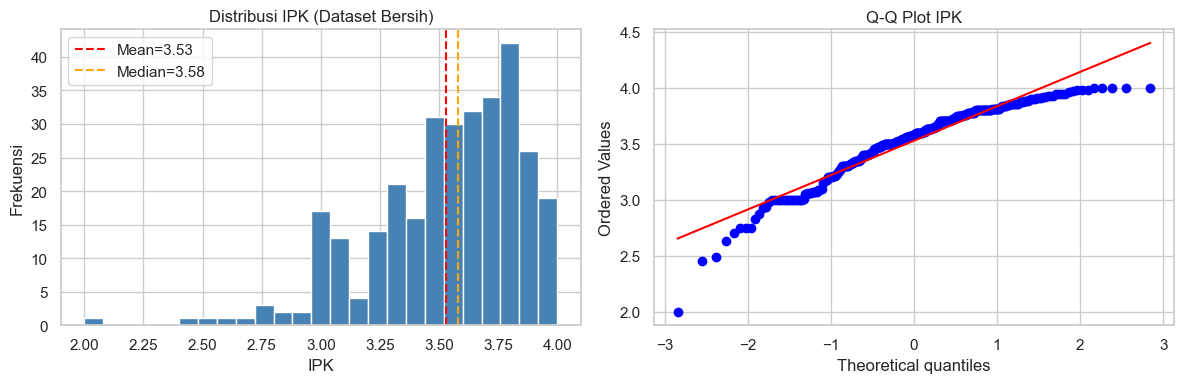

Interpretasi: Distribusi IPK mendekati normal dengan sedikit left-skew.
Q-Q plot mengonfirmasi distribusi cukup normal untuk digunakan pada model linear.


In [87]:
# ── A. Distribusi Target IPK (final, setelah cleaning) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean={y.mean():.2f}')
axes[0].axvline(y.median(), color='orange', linestyle='--', label=f'Median={y.median():.2f}')
axes[0].set_title('Distribusi IPK (Dataset Bersih)')
axes[0].set_xlabel('IPK'); axes[0].set_ylabel('Frekuensi')
axes[0].legend()

import scipy.stats as stats
stats.probplot(y, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot IPK')

plt.tight_layout()
plt.savefig('viz_A_ipk_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Distribusi IPK mendekati normal dengan sedikit left-skew.")
print("Q-Q plot mengonfirmasi distribusi cukup normal untuk digunakan pada model linear.")


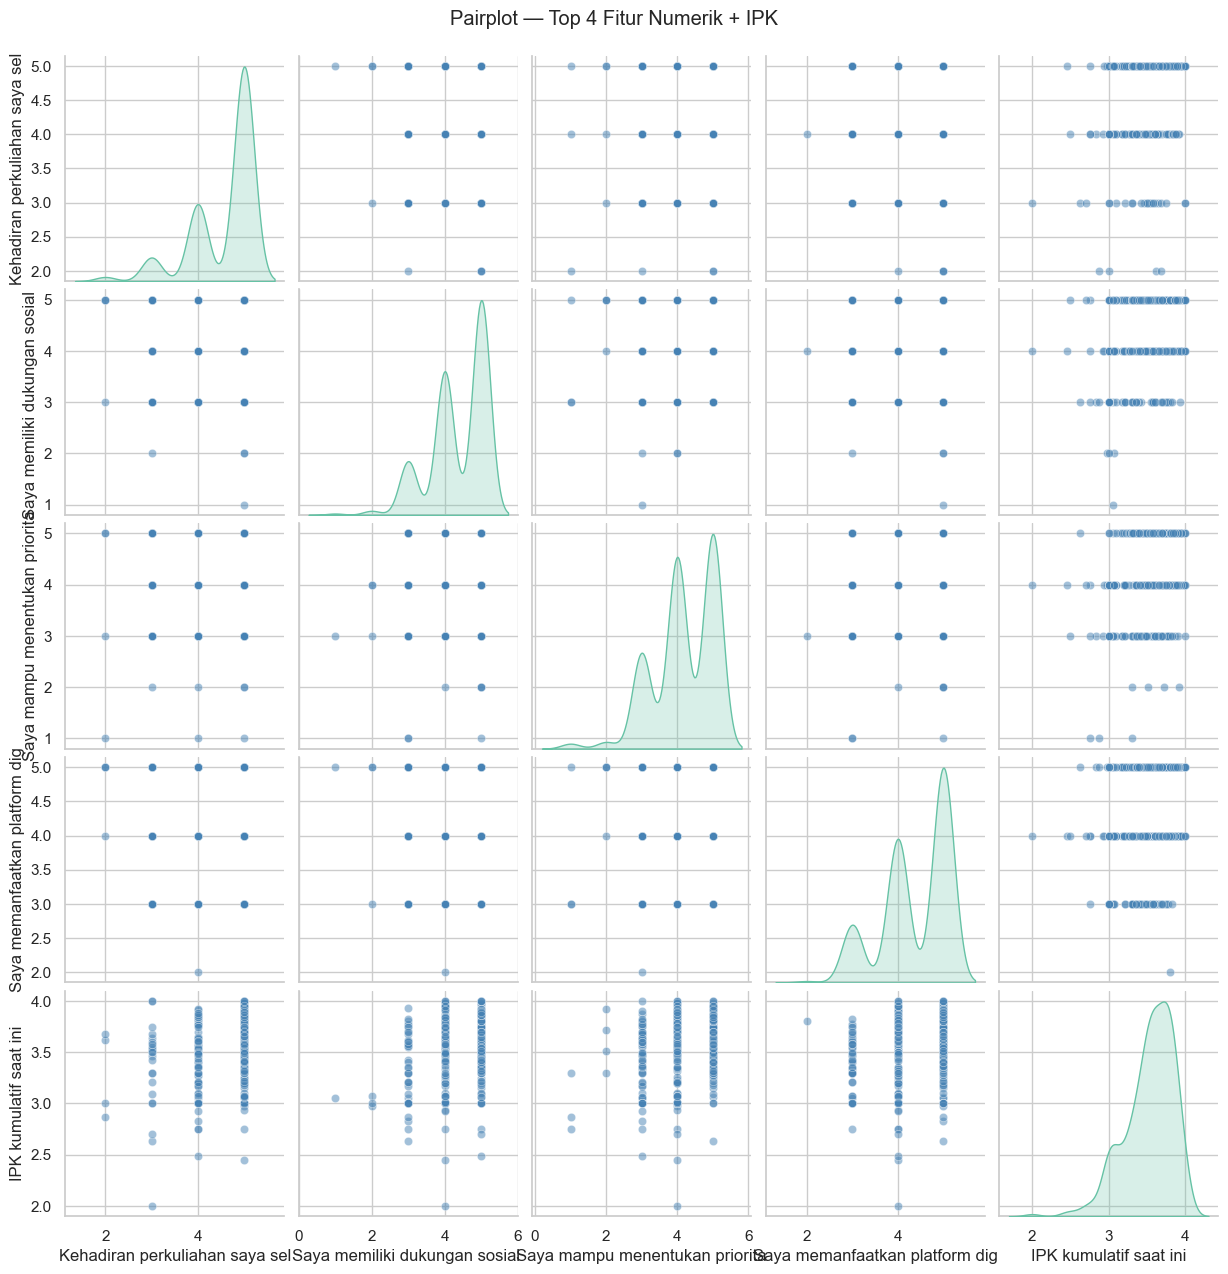

Interpretasi: Pairplot menampilkan hubungan bivariat antar fitur terpilih.
Pola linear yang jelas menunjukkan fitur yang baik untuk model regresi linear.


In [88]:
# ── B. Pairplot fitur numerik penting ────────────────────────────────────────
pairplot_cols = corr_with_ipk.head(4).index.tolist() + [col_ipk]
pairplot_data = df[pairplot_cols].dropna()
pairplot_data.columns = [c.strip()[:30] for c in pairplot_data.columns]

pp = sns.pairplot(pairplot_data, diag_kind='kde',
                  plot_kws={'alpha': 0.5, 'color': 'steelblue'})
pp.fig.suptitle('Pairplot — Top 4 Fitur Numerik + IPK', y=1.02)
pp.savefig('viz_B_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print("Interpretasi: Pairplot menampilkan hubungan bivariat antar fitur terpilih.")
print("Pola linear yang jelas menunjukkan fitur yang baik untuk model regresi linear.")


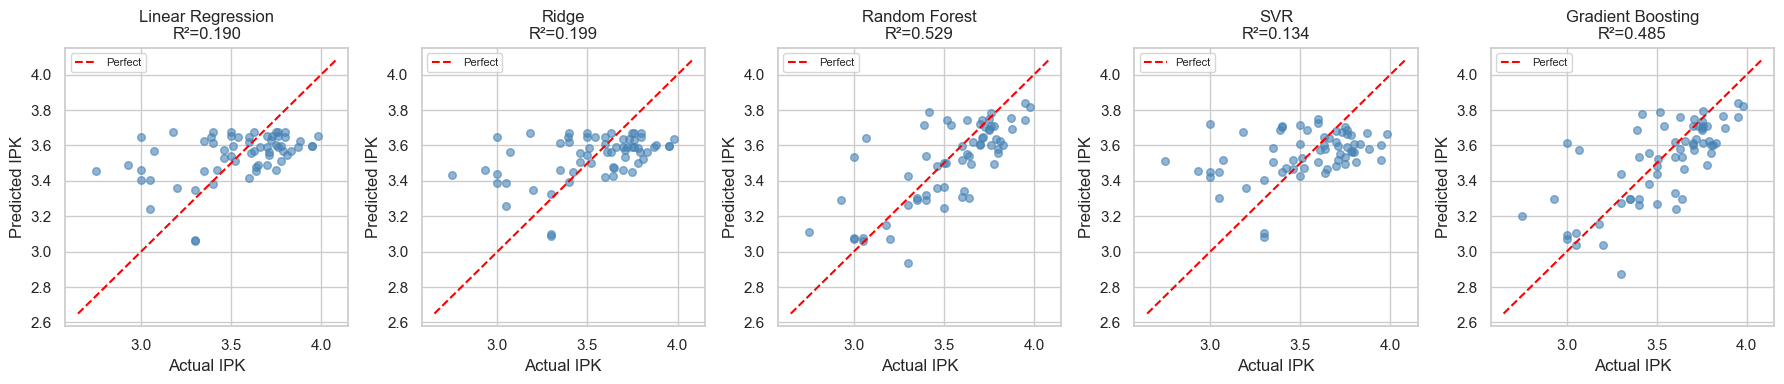

Interpretasi: Titik-titik mendekati garis merah (perfect prediction) menunjukkan
prediksi yang akurat. Penyebaran yang merata mengindikasikan tidak ada bias sistematis.


In [89]:
# ── C. Predicted vs Actual ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(best_models), figsize=(18, 4))

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    axes[idx].scatter(y_test, y_pred, alpha=0.6, color='steelblue', s=30)
    lims = [min(y_test.min(), y_pred.min()) - 0.1,
            max(y_test.max(), y_pred.max()) + 0.1]
    axes[idx].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
    axes[idx].set_xlabel('Actual IPK')
    axes[idx].set_ylabel('Predicted IPK')
    r2_val = r2_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nR²={r2_val:.3f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('viz_C_pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Titik-titik mendekati garis merah (perfect prediction) menunjukkan")
print("prediksi yang akurat. Penyebaran yang merata mengindikasikan tidak ada bias sistematis.")


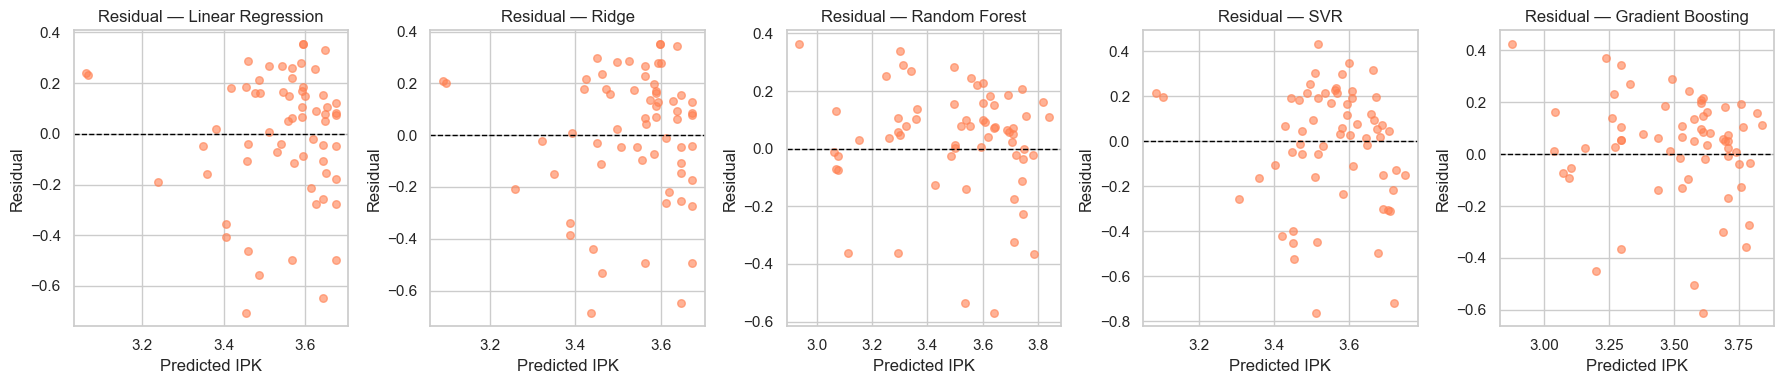

Interpretasi: Residual yang tersebar acak di sekitar 0 menunjukkan model telah
menangkap pola data dengan baik. Pola tertentu (corong/kurva) mengindikasikan
masalah seperti heteroskedastisitas atau hubungan non-linear yang belum tertangkap.


In [90]:
# ── D. Residual Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(best_models), figsize=(18, 4))

for idx, (name, model) in enumerate(best_models.items()):
    y_pred   = model.predict(X_test)
    residuals = y_test - y_pred
    axes[idx].scatter(y_pred, residuals, alpha=0.6, color='coral', s=30)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[idx].set_xlabel('Predicted IPK')
    axes[idx].set_ylabel('Residual')
    axes[idx].set_title(f'Residual — {name}')

plt.tight_layout()
plt.savefig('viz_D_residual.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Residual yang tersebar acak di sekitar 0 menunjukkan model telah")
print("menangkap pola data dengan baik. Pola tertentu (corong/kurva) mengindikasikan")
print("masalah seperti heteroskedastisitas atau hubungan non-linear yang belum tertangkap.")


In [91]:
# ── E. 20 Data Test Pertama — Actual vs Predicted ────────────────────────────
best_name = eval_df.iloc[0]['Model']
best_model = best_models[best_name]

y_pred_best = best_model.predict(X_test)

# Tabel 20 data pertama
sample20 = pd.DataFrame({
    'No'        : range(1, 21),
    'Actual IPK': y_test.iloc[:20].values.round(2),
    'Predicted' : y_pred_best[:20].round(2),
    'Error'     : (y_test.iloc[:20].values - y_pred_best[:20]).round(3),
    'Abs Error' : np.abs(y_test.iloc[:20].values - y_pred_best[:20]).round(3)
}).set_index('No')

print(f"20 Data Test Pertama — Model: {best_name}")
display(sample20)
print(f"\nMAE 20 sampel: {sample20['Abs Error'].mean():.4f}")


20 Data Test Pertama — Model: Random Forest


,Actual IPK,Predicted,Error,Abs Error
No,,,,
1,3.78,3.50,0.284,0.284
2,2.75,3.11,-0.362,0.362
3,2.93,3.29,-0.362,0.362
4,3.66,3.62,0.041,0.041
5,3.51,3.50,0.012,0.012
6,3.64,3.54,0.101,0.101
7,3.65,3.49,0.156,0.156
8,3.00,3.07,-0.075,0.075
9,3.39,3.71,-0.323,0.323



MAE 20 sampel: 0.1961


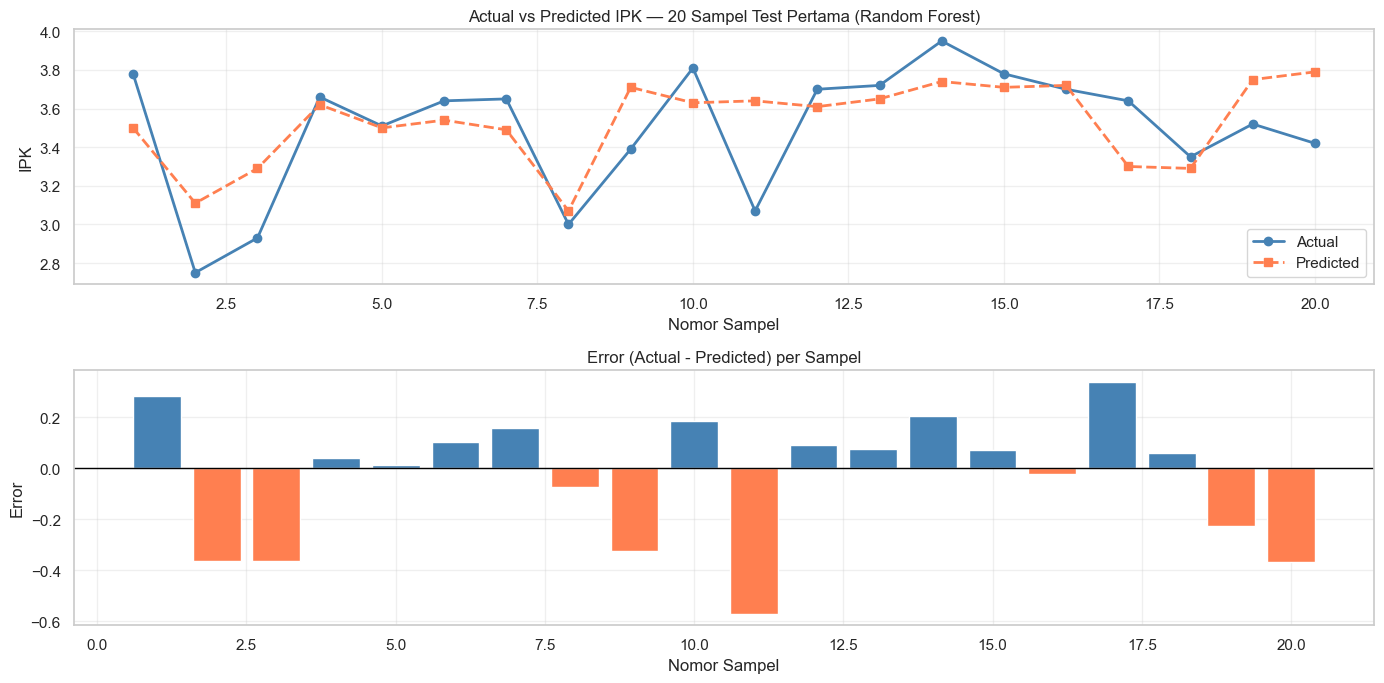

Interpretasi: Grafik perbandingan menampilkan seberapa dekat prediksi model
dengan nilai aktual pada 20 sampel test pertama.


In [92]:
# ── Grafik perbandingan 20 sampel ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

x20 = np.arange(1, 21)
axes[0].plot(x20, sample20['Actual IPK'], 'o-', color='steelblue', label='Actual', linewidth=2)
axes[0].plot(x20, sample20['Predicted'], 's--', color='coral', label='Predicted', linewidth=2)
axes[0].set_title(f'Actual vs Predicted IPK — 20 Sampel Test Pertama ({best_name})')
axes[0].set_xlabel('Nomor Sampel'); axes[0].set_ylabel('IPK')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].bar(x20, sample20['Error'], color=['steelblue' if e >= 0 else 'coral'
                                             for e in sample20['Error']])
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Error (Actual - Predicted) per Sampel')
axes[1].set_xlabel('Nomor Sampel'); axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_E_20samples.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Grafik perbandingan menampilkan seberapa dekat prediksi model")
print("dengan nilai aktual pada 20 sampel test pertama.")


## 17. Perbandingan Model

Tabel Perbandingan Model (diurutkan R² terbaik):


,Model,R²,MAE,MSE,RMSE
0,Random Forest,0.5289,0.1451,0.0371,0.1926
1,Gradient Boosting,0.4852,0.1516,0.0405,0.2013
2,Ridge,0.1988,0.2016,0.0631,0.2511
3,Linear Regression,0.1899,0.2014,0.0638,0.2525
4,SVR,0.1338,0.2054,0.0682,0.2611


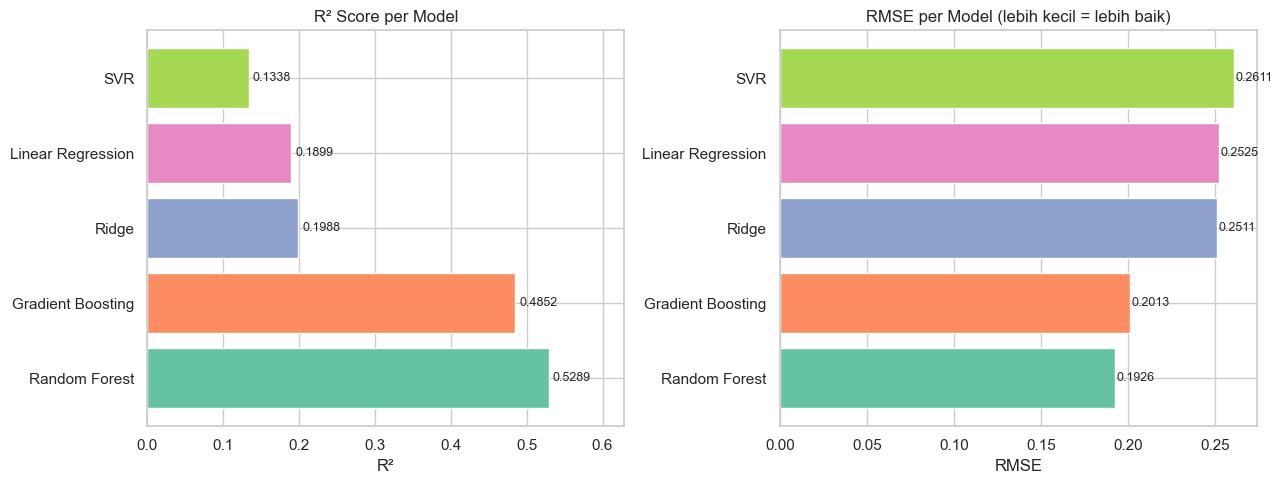

In [93]:
print("Tabel Perbandingan Model (diurutkan R² terbaik):")
display(eval_df)

# ── Grafik perbandingan R² dan RMSE ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = sns.color_palette('Set2', len(eval_df))

# R²
bars = axes[0].barh(eval_df['Model'], eval_df['R²'], color=colors)
for bar, val in zip(bars, eval_df['R²']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                  f'{val:.4f}', va='center', fontsize=9)
axes[0].set_title('R² Score per Model')
axes[0].set_xlabel('R²')
axes[0].set_xlim(0, max(eval_df['R²']) + 0.1)

# RMSE
eval_sorted_rmse = eval_df.sort_values('RMSE')
bars2 = axes[1].barh(eval_sorted_rmse['Model'], eval_sorted_rmse['RMSE'], color=colors)
for bar, val in zip(bars2, eval_sorted_rmse['RMSE']):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                  f'{val:.4f}', va='center', fontsize=9)
axes[1].set_title('RMSE per Model (lebih kecil = lebih baik)')
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.savefig('model_comparison_regression.png', dpi=120, bbox_inches='tight')
plt.show()


## 18. Analisis Feature Importance

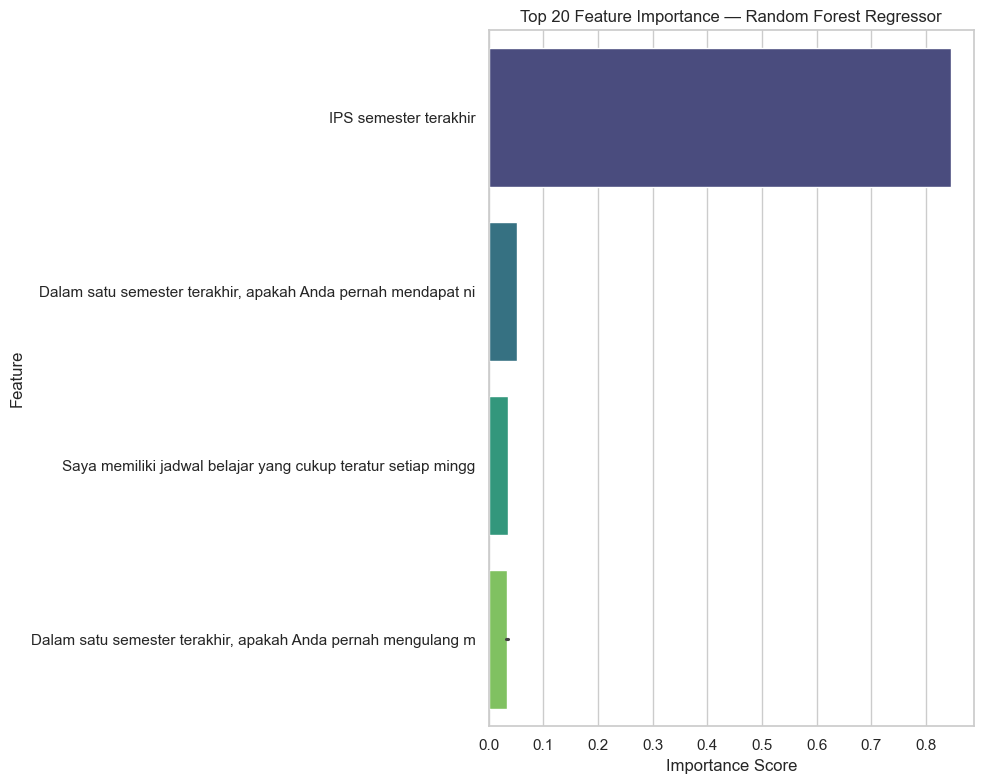

Interpretasi: Fitur dengan importance tinggi paling berpengaruh dalam prediksi IPK.
IPS semester terakhir umumnya dominan karena berkorelasi langsung dengan IPK kumulatif.


In [94]:
# ── Feature Importance dari Random Forest ────────────────────────────────────
rf_best = gs_rf.best_estimator_

ohe_rf = rf_best.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
cat_fn = list(ohe_rf.get_feature_names_out(CAT_FEATURES))
all_fn = NUM_FEATURES + cat_fn

sel_rf   = rf_best.named_steps['selector']
sel_mask = sel_rf.get_support()
sel_fn   = [all_fn[i] for i, s in enumerate(sel_mask) if s]

fi_values = rf_best.named_steps['reg'].feature_importances_
fi_df = pd.DataFrame({
    'Feature'   : [f.strip()[:60] for f in sel_fn],
    'Importance': fi_values
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importance — Random Forest Regressor')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fi_random_forest.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Fitur dengan importance tinggi paling berpengaruh dalam prediksi IPK.")
print("IPS semester terakhir umumnya dominan karena berkorelasi langsung dengan IPK kumulatif.")


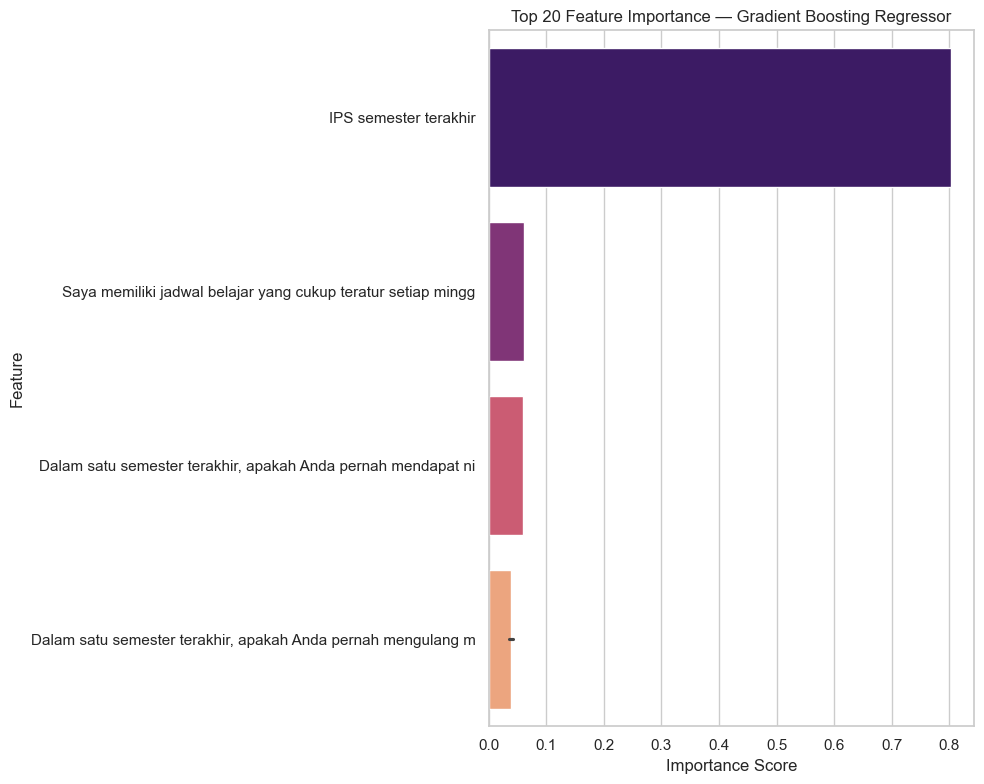

Interpretasi: Gradient Boosting cenderung memilih fitur yang berbeda dari Random Forest
karena proses boosting iteratif memanfaatkan residual setiap iterasi.


In [95]:
# ── Feature Importance dari Gradient Boosting ─────────────────────────────────
gb_best = gs_gb.best_estimator_

ohe_gb = gb_best.named_steps['prep'].named_transformers_['cat'].named_steps['encoder']
cat_fn_gb = list(ohe_gb.get_feature_names_out(CAT_FEATURES))
all_fn_gb = NUM_FEATURES + cat_fn_gb

sel_gb   = gb_best.named_steps['selector']
sel_mask_gb = sel_gb.get_support()
sel_fn_gb = [all_fn_gb[i] for i, s in enumerate(sel_mask_gb) if s]

fi_gb = pd.DataFrame({
    'Feature'   : [f.strip()[:60] for f in sel_fn_gb],
    'Importance': gb_best.named_steps['reg'].feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=fi_gb, x='Importance', y='Feature', palette='magma')
plt.title('Top 20 Feature Importance — Gradient Boosting Regressor')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fi_gradient_boosting.png', dpi=120, bbox_inches='tight')
plt.show()
print("Interpretasi: Gradient Boosting cenderung memilih fitur yang berbeda dari Random Forest")
print("karena proses boosting iteratif memanfaatkan residual setiap iterasi.")


## 19. Pemilihan Model Terbaik

In [96]:
print("=== Evaluasi Final (Test Set) ===")
display(eval_df)
print()
print("=== Stabilitas Cross Validation ===")
display(cv_df[['Model','CV R² Mean','CV R² Std','CV RMSE Mean','CV RMSE Std']])

best_name = eval_df.iloc[0]['Model']
best_r2   = eval_df.iloc[0]['R²']
best_rmse = eval_df.iloc[0]['RMSE']

print(f"\n✅ MODEL TERBAIK: {best_name}")
print(f"   R²   (Test Set): {best_r2:.4f}")
print(f"   RMSE (Test Set): {best_rmse:.4f}")
print(f"""
Alasan pemilihan model {best_name}:
1. R² Tertinggi   — menjelaskan proporsi variansi IPK terbesar di antara semua model.
2. RMSE Terendah  — kesalahan prediksi rata-rata (dalam satuan IPK) terkecil.
3. Stabilitas CV  — CV R² Std rendah menunjukkan model tidak overfit dan performanya
                    konsisten lintas fold.
4. Interpretabilitas — hasil feature importance dapat diinterpretasikan untuk
                       memahami faktor-faktor yang memengaruhi IPK mahasiswa.
""")


=== Evaluasi Final (Test Set) ===


,Model,R²,MAE,MSE,RMSE
0,Random Forest,0.5289,0.1451,0.0371,0.1926
1,Gradient Boosting,0.4852,0.1516,0.0405,0.2013
2,Ridge,0.1988,0.2016,0.0631,0.2511
3,Linear Regression,0.1899,0.2014,0.0638,0.2525
4,SVR,0.1338,0.2054,0.0682,0.2611



=== Stabilitas Cross Validation ===


,Model,CV R² Mean,CV R² Std,CV RMSE Mean,CV RMSE Std
0,Gradient Boosting,0.3476,0.1534,0.2473,0.0420
1,Random Forest,0.3219,0.1882,0.2489,0.0383
2,Ridge,0.1553,0.0837,0.2910,0.0385
3,Linear Regression,0.1524,0.0941,0.2910,0.0368
4,SVR,0.0935,0.1594,0.3004,0.0448



✅ MODEL TERBAIK: Random Forest
   R²   (Test Set): 0.5289
   RMSE (Test Set): 0.1926

Alasan pemilihan model Random Forest:
1. R² Tertinggi   — menjelaskan proporsi variansi IPK terbesar di antara semua model.
2. RMSE Terendah  — kesalahan prediksi rata-rata (dalam satuan IPK) terkecil.
3. Stabilitas CV  — CV R² Std rendah menunjukkan model tidak overfit dan performanya
                    konsisten lintas fold.
4. Interpretabilitas — hasil feature importance dapat diinterpretasikan untuk
                       memahami faktor-faktor yang memengaruhi IPK mahasiswa.



## 20. Export Model

In [97]:
best_estimator_map = {
    'Linear Regression' : gs_lr.best_estimator_,
    'Ridge'             : gs_ridge.best_estimator_,
    'Random Forest'     : gs_rf.best_estimator_,
    'SVR'               : gs_svr.best_estimator_,
    'Gradient Boosting' : gs_gb.best_estimator_,
}

best_pipeline = best_estimator_map[best_name]

output_path = 'BestModel_Regresi_Alg_William Luvianus_Selly Monica.pkl'
joblib.dump(best_pipeline, output_path)
print(f"✅ Model terbaik ({best_name}) disimpan ke: {output_path}")

# ── Verifikasi ────────────────────────────────────────────────────────────────
loaded = joblib.load(output_path)
sample_pred = loaded.predict(X_test.iloc[:5])
print(f"\nVerifikasi prediksi 5 sampel:")
print(f"  Prediksi : {sample_pred.round(3).tolist()}")
print(f"  Aktual   : {y_test.iloc[:5].round(3).tolist()}")
print("\n✅ Model berhasil dimuat dan diverifikasi.")


✅ Model terbaik (Random Forest) disimpan ke: BestModel_Regresi_Alg_William Luvianus_Selly Monica.pkl

Verifikasi prediksi 5 sampel:
  Prediksi : [3.496, 3.112, 3.292, 3.619, 3.498]
  Aktual   : [3.78, 2.75, 2.93, 3.66, 3.51]

✅ Model berhasil dimuat dan diverifikasi.


---
## Kesimpulan

1. **Dataset** berisi 311 data bersih setelah membuang 12 baris IPK tidak valid (> 4.0) dan 1 baris missing massif.
2. **Target** adalah IPK kumulatif (kontinu, 0–4.0).
3. **Fitur LearningStyle** dibuat ulang menggunakan aturan VARK yang sama dengan Notebook 1 dan digunakan sebagai prediktor kategorikal.
4. **5 model regresi** dibandingkan menggunakan pipeline lengkap dengan GridSearchCV dan KFold cross validation.
5. **Model terbaik** dipilih berdasarkan kombinasi R² tertinggi, RMSE terendah, dan stabilitas CV.
6. Model diekspor ke `BestModel_Regresi_Alg_William Luvianus_Selly Monica.pkl` siap digunakan di aplikasi Streamlit.
